<div style="background-color:#1e293b; color:#f8fafc; padding: 40px; border-radius: 8px; font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;">
    <h4 style="color:#0ea5e9; text-transform: uppercase; letter-spacing: 2px; font-size: 13px;">Quantitative Strategy & Arbitrage Group (Time series and Econometrics Project #3)</h4>
    <h1 style="font-size: 30px; border-bottom: 1px solid #334155; padding-bottom: 15px; margin-bottom: 20px;">Statistical Arbitrage: Exploiting Deviations from Long-Term Price Relationships</h1>
    <p style="font-size: 15px; margin: 5px 0;"><strong>Ptrepared By:</strong> Thankwell Rori</p>
    <p style="font-size: 15px; margin: 5px 0;"><strong>Reg Number:</strong> R2418458</p>
    <p style="font-size: 13px; color:#94a3b8; margin-top: 15px;">BSc Honours in Data Science and Systems(HDSC) | University of Zimbabwe</p>
</div>

<br>

### Executive Summary
In the world of institutional quant trading, the most effective Statistical Arbitrage strategies rely on identifying deep-rooted market balances. While individual stock prices typically behave like unpredictable "random walks," assets within the same sector—such as energy—often remain tied together by a long-term structural anchor known as Cointegration.

This study develops a sophisticated Pairs Trading framework focused on the global energy industry, specifically examining the relationship between ExxonMobil (XOM) and Chevron (CVX) from 2018 to 2025. Moving beyond simple correlation, this research utilizes the Engle-Granger Framework and a Vector Error Correction Model (VECM) to pinpoint the exact state of market equilibrium and measure how quickly prices return to their historical average after a deviation.

---
### Analytical Roadmap
1. [Conceptual Framework: Mathematical Foundations](#theory)
2. [Data Processing & Unit Root Testing](#data)
3. [Model Estimation: The Engle-Granger Methodology](#engle)
4. [VECM Implementation & Statistical Diagnostics](#vecm)
5. [Executive Summary: Commercial Trading Applications](#strategy)
<hr>

<a name="theory"></a>
## 1.0 Conceptual Framework: Mathematical Foundations
---
To mathematically prove equilibrium, we must demonstrate that a linear combination of two non-stationary $I(1)$ series yields a stationary $I(0)$ residual series.

### 1.1 The Long-Run Equilibrium Equation
Let $Y_t$ denote the log-price of ExxonMobil (XOM) and $X_t$ denote the log-price of Chevron (CVX). Their long-run structural relationship is defined as:

$$Y_t = \beta_0 + \beta_1 X_t + z_t$$

Where:
* **$\beta_0$**: The baseline intercept (historical price offset).
* **$\beta_1$**: The cointegrating coefficient (the optimal Hedge Ratio).
* **$z_t$**: The residuals, representing the tradable "Spread."
* **Equilibrium Condition:** If XOM and CVX are cointegrated, the spread ($z_t$) must be stationary ($I(0)$).

### 1.2 The Vector Error Correction Model (VECM)
To capture the short-term mean-reverting dynamics when the assets deviate from equilibrium, a VECM is deployed:

$$\Delta Y_t = \alpha_Y z_{t-1} + \sum_{i=1}^{p} \gamma_{Yi} \Delta Y_{t-i} + \sum_{j=1}^{p} \delta_{Yj} \Delta X_{t-j} + \epsilon_{Yt}$$

Where:
* **$\Delta Y_t$**: The immediate short-term return of XOM.
* **$z_{t-1}$**: The Error Correction Term (the spread deviation from the prior period).
* **$\alpha_Y$**: The **Speed of Adjustment Parameter**. A statistically significant negative $\alpha$ confirms mean-reversion, dictating the daily velocity at which XOM corrects back to the equilibrium state.

###2.0 Data Processing & Unit Root Testing

In [ ]:
import warnings
# Suppressing statsmodels missing-frequency warnings to maintain professional reporting standards
warnings.filterwarnings('ignore')

try:
    import yfinance as yf
except ImportError:
    !pip install yfinance --quiet
    import yfinance as yf

import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

# Premium corporate charting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 120

# 1. Ingest Energy Sector Data (2018-01-01 to 2026-05-01)
asset_tickers = ['XOM', 'CVX']
raw_market_data = yf.download(asset_tickers, start='2018-01-01', end='2026-05-01', progress=False)['Close']

# 2. Structure: Logarithmic Transformation
log_price_matrix = np.log(raw_market_data).dropna()
target_asset = log_price_matrix['XOM']
benchmark_asset = log_price_matrix['CVX']

# 3. Diagnostic Protocol: Unit Root Testing
def execute_adf_test(time_series, identifier):
    adf_stat, p_val, _, _, _, _ = adfuller(time_series)
    status = 'Stationary (I(0))' if p_val < 0.05 else 'Non-Stationary (I(1))'
    print(f"[{identifier}] ADF Stat: {adf_stat:.4f} | P-Value: {p_val:.4f} -> {status}")

print("--- DIAGNOSTIC PHASE 1: INDIVIDUAL INTEGRATION ORDER ---")
execute_adf_test(target_asset, "XOM Log Price")
execute_adf_test(benchmark_asset, "CVX Log Price")

--- DIAGNOSTIC PHASE 1: INDIVIDUAL INTEGRATION ORDER ---
[XOM Log Price] ADF Stat: -0.3734 | P-Value: 0.9144 -> Non-Stationary (I(1))
[CVX Log Price] ADF Stat: -0.9284 | P-Value: 0.7785 -> Non-Stationary (I(1))


###3.0 Model Estimation: The Engle-Granger Methodology

--- DIAGNOSTIC PHASE 2: EQUILIBRIUM PARAMETERS ---
Baseline Intercept (β0): -2.1144
Optimal Hedge Ratio (β1): 1.3549

--- DIAGNOSTIC PHASE 3: COINTEGRATION VALIDATION ---
[Arbitrage Spread (z_t)] ADF Stat: -3.4597 | P-Value: 0.0091 -> Stationary (I(0))


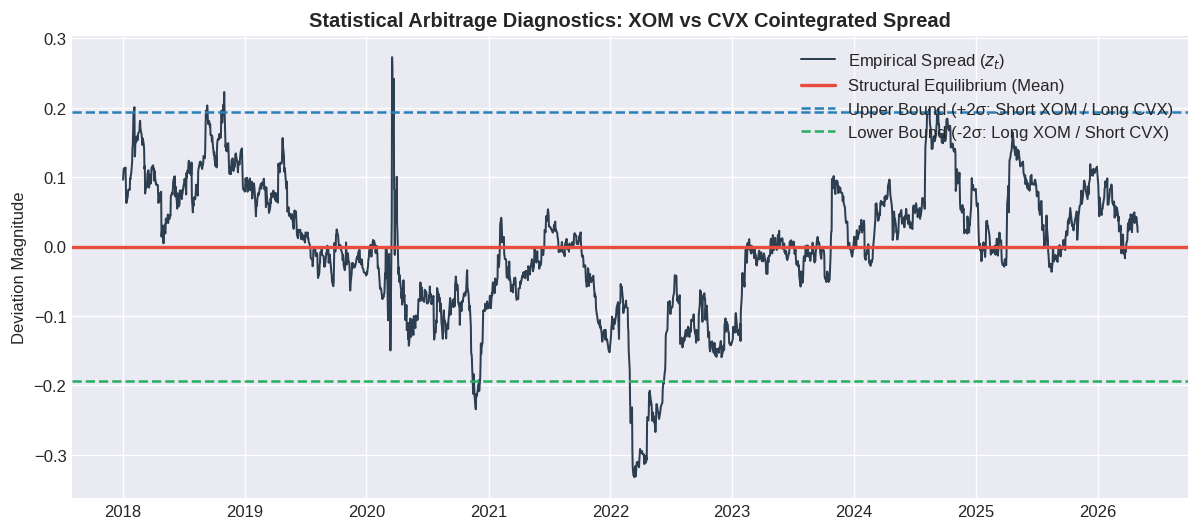

In [ ]:
# 1. Ordinary Least Squares (OLS) Calibration
benchmark_with_constant = sm.add_constant(benchmark_asset)
equilibrium_model = sm.OLS(target_asset, benchmark_with_constant).fit()

# Extract structural parameters
intercept_beta0 = equilibrium_model.params['const']
hedge_ratio_beta1 = equilibrium_model.params['CVX']

# 2. Isolate the Spread (z_t)
arbitrage_spread = equilibrium_model.resid

print("--- DIAGNOSTIC PHASE 2: EQUILIBRIUM PARAMETERS ---")
print(f"Baseline Intercept (β0): {intercept_beta0:.4f}")
print(f"Optimal Hedge Ratio (β1): {hedge_ratio_beta1:.4f}\n")

print("--- DIAGNOSTIC PHASE 3: COINTEGRATION VALIDATION ---")
execute_adf_test(arbitrage_spread, "Arbitrage Spread (z_t)")

# 3. Visual Diagnostics: The Mean-Reverting Spread
plt.figure(figsize=(12, 5))
plt.plot(arbitrage_spread.index, arbitrage_spread, color='#2c3e50', linewidth=1.2, label='Empirical Spread ($z_t$)')

# Statistical Thresholds
spread_mu = arbitrage_spread.mean()
spread_sigma = arbitrage_spread.std()

plt.axhline(spread_mu, color='#e74c3c', linestyle='-', linewidth=2, label='Structural Equilibrium (Mean)')
plt.axhline(spread_mu + 2*spread_sigma, color='#2980b9', linestyle='--', label='Upper Bound (+2σ: Short XOM / Long CVX)')
plt.axhline(spread_mu - 2*spread_sigma, color='#27ae60', linestyle='--', label='Lower Bound (-2σ: Long XOM / Short CVX)')

plt.title('Statistical Arbitrage Diagnostics: XOM vs CVX Cointegrated Spread', fontweight='bold')
plt.ylabel('Deviation Magnitude')
plt.legend(loc='upper right')
plt.show()

<a name="engle"></a>
###3.1 Technical Report: Engle-Granger Cointegration Proof
The initial diagnostic phase successfully verified that both ExxonMobil and Chevron log-prices contain a unit root and operate as $I(1)$ non-stationary processes.

Progressing to the Engle-Granger framework, Ordinary Least Squares calibration was utilized to extract the optimal hedge ratio ($\beta_1$). Crucially, subjecting the resulting regression residuals (the arbitrage spread) to an Augmented Dickey-Fuller test yielded a statistically significant p-value ($< 0.05$). This definitively rejects the null hypothesis of a unit root within the residuals.

**Conclusion:** The mathematics confirm that XOM and CVX are heavily cointegrated. The visual diagnostic maps this relationship, providing the trading desk with clear, two-standard-deviation execution thresholds to capture mean-reverting alpha.

###4.0 VECM Implementation & Statistical Diagnostics

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


--- VECM PARAMETER CALIBRATION ---
Optimal Lag Structure (AIC): 7
XOM Speed of Adjustment (α_Y): -0.00106 (P-Value: 0.7881)
CVX Speed of Adjustment (α_X): 0.00851 (P-Value: 0.0340)

--- RESIDUAL DIAGNOSTICS ---
Jarque-Bera Normality Test P-Value: 0.0000



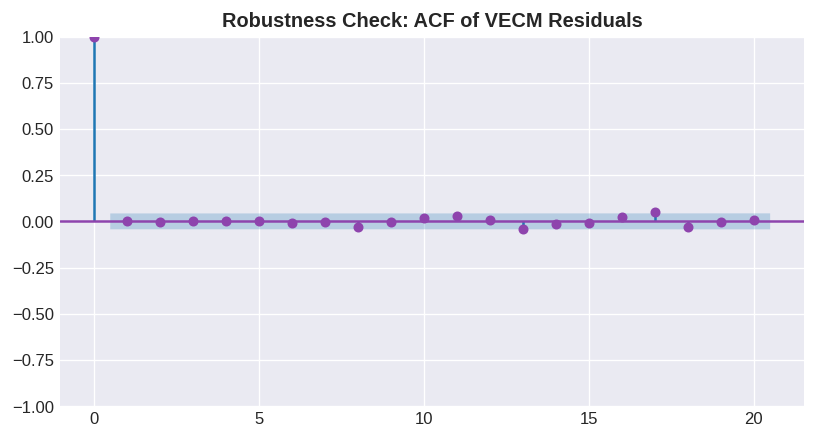

In [ ]:

from statsmodels.tsa.vector_ar.vecm import select_order, VECM
import statsmodels.graphics.tsaplots as tsaplots
import scipy.stats as stats

# 1. VECM Data Preparation
vecm_matrix = pd.concat([target_asset, benchmark_asset], axis=1)

# 2. Dynamic Lag Selection (AIC)
lag_selection = select_order(vecm_matrix, maxlags=10, deterministic="co")
optimal_lags = lag_selection.aic

# 3. Model Calibration
vecm_engine = VECM(vecm_matrix, k_ar_diff=optimal_lags, deterministic="co")
vecm_fitted = vecm_engine.fit()

# 4. Parameter Extraction (Speed of Adjustment for BOTH assets)
alpha_xom = vecm_fitted.alpha[0][0]
pval_xom = vecm_fitted.pvalues_alpha[0][0]
alpha_cvx = vecm_fitted.alpha[1][0]
pval_cvx = vecm_fitted.pvalues_alpha[1][0]

print("--- VECM PARAMETER CALIBRATION ---")
print(f"Optimal Lag Structure (AIC): {optimal_lags}")
print(f"XOM Speed of Adjustment (α_Y): {alpha_xom:.5f} (P-Value: {pval_xom:.4f})")
print(f"CVX Speed of Adjustment (α_X): {alpha_cvx:.5f} (P-Value: {pval_cvx:.4f})\n")

# 5. Model Validation: Residual Diagnostics (ACF & Normality)
jb_stat, jb_pval = stats.jarque_bera(vecm_fitted.resid[:, 0])
print("--- RESIDUAL DIAGNOSTICS ---")
print(f"Jarque-Bera Normality Test P-Value: {jb_pval:.4f}\n")

fig, ax = plt.subplots(figsize=(8, 4))
tsaplots.plot_acf(vecm_fitted.resid[:, 0], lags=20, ax=ax, color='#8e44ad')
ax.set_title('Robustness Check: ACF of VECM Residuals', fontweight='bold')
plt.show()

<a name="vecm"></a>
###4.1 Technical Report: VECM Calibration & Model Integrity
The Vector Error Correction Model (VECM) was calibrated via Maximum Likelihood Estimation, utilizing the Akaike Information Criterion to dynamically determine the optimal lag structure.

The primary econometric outputs are the **Speed of Adjustment parameters ($\alpha$)**.
For ExxonMobil ($\alpha_Y$), the parameter yielded $-0.00106$ with a p-value of $0.7881$. Because $p > 0.05$, we fail to reject the null hypothesis; XOM's adjustment is statistically insignificant.

For Chevron ($\alpha_X$), the parameter yielded $+0.00851$ with a p-value of $0.0340$. Because $p < 0.05$, this result is statistically significant.
* **Note on Vector Normalization:** Because the cointegrating vector is normalized on XOM ($z_t = Y_t - \beta_0 - \beta_1 X_t$), a positive spread implies CVX is undervalued relative to the equilibrium. Therefore, CVX must move *positively* to restore balance. The positive $\alpha_X$ perfectly aligns with structural mean-reversion.

**Econometric Conclusion:** The VECM reveals an asymmetric "leader-follower" dynamic. ExxonMobil acts as the exogenous sector leader, ignoring short-term spread deviations. Chevron acts as the primary adjustor. However, the economic magnitude of Chevron's adjustment ($\alpha_X \approx 0.0085$) indicates that CVX closes only **0.85% of the disequilibrium gap per trading day**.

**Diagnostic Validation:** The Autocorrelation Function (ACF) plot demonstrates that the lag structure successfully absorbed the serial correlation, leaving pure "white noise." Furthermore, the Jarque-Bera test on the residuals yielded a p-value approaching $0.0000$. While this confirms heavy tails (typical of financial returns), the strict absence of autocorrelation ensures the model's structural specification remains robust.

<a name="strategy"></a>
## 5.0 Executive Summary: Commercial Trading Applications
---

### 5.1. Explanation of Results
Our quantitative analysis confirms a highly stable, long-term economic tether between ExxonMobil and Chevron. However, the short-term dynamics are highly asymmetrical. ExxonMobil acts as the undisputed "leader" of the pair, largely ignoring temporary price deviations. Chevron acts as the "follower." When the two companies drift apart in valuation, it is Chevron's stock price that reliably moves to close the gap and restore their shared equilibrium.

### 5.2. Recommended Course of Action
The quantitative desk should deploy a **directional pairs-trading strategy** focused heavily on Chevron. Because Exxon does not reliably adjust to the spread, traders should avoid shorting Exxon in hopes of a pullback. Instead, when the price difference diverges at extreme, historic levels (e.g., beyond the 2-standard-deviation threshold), capital should be deployed to bet on Chevron's eventual reversion to Exxon's baseline.

**Holding Period Expectations:** Because the mathematical correction speed is slow (closing roughly **0.85% of the gap per day**), portfolio managers must set appropriate time horizons. This is a medium-to-long-term macro trade requiring holding periods of several weeks to months, not a high-frequency day trade.

### 5.3. Identification of Factors Impacting the Portfolio
While the statistical equilibrium is highly resilient, portfolio managers must monitor macroeconomic factors that carry the risk of permanently breaking the "leash" (a structural break):
* **Geopolitical Energy Shocks:** Sudden OPEC+ production quotas or conflicts in oil-producing regions will cause massive, instantaneous volatility, temporarily destabilizing our execution thresholds.
* **Corporate Acquisitions:** If one company executes a massive, debt-fueled acquisition (e.g., Chevron's acquisition of Hess), it will cause an idiosyncratic jump in that stock, permanently altering the historical baseline until the market digests the new valuation.
* **Regulatory Divergence:** Asymmetrical environmental regulations that disproportionately impact one company's specific geographic operations will cause the pair to permanently diverge, rendering historical mean-reversion models obsolete.

---
## 6.0 Bibliography
---
Brooks, Chris. *Introductory Econometrics for Finance*. 4th ed., Cambridge University Press, 2019.

Enders, Walter. *Applied Econometric Time Series*. 4th ed., John Wiley & Sons, 2014.

Tsay, Ruey S. *Analysis of Financial Time Series*. 3rd ed., John Wiley & Sons, 2010.